In [145]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [146]:
TRAIN_DIR = 'train'
TEST_DIR = 'test'

train_df = pd.read_csv('train.csv')
print("Train dataset length: ", len(train_df))
print(train_df.head())

Train dataset length:  17000
      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3


In [147]:
images = []
labels = []

for i in range(len(train_df)):
    image_id = train_df["Id"][i]
    label = train_df["Category"][i]
    path = TRAIN_DIR + "/" + str(label) + "/" + str(image_id) + ".png"
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    images.append(image)
    labels.append(label)

X_raw = np.array(images)
y = np.array(labels)

print(X_raw.shape)
print(y.shape)

(17000, 32, 32)
(17000,)


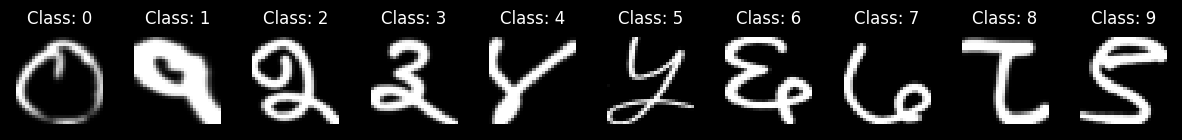

In [148]:
plt.figure(figsize=(15, 2))

for i in range(10):
    img_index = np.where(y == i)[0][0]
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_raw[img_index], cmap='gray')
    plt.title(f"Class: {i}")
    plt.axis('off')

plt.show()

In [149]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_raw, y, test_size=0.2, stratify=y, random_state=42)
print("Train: ", X_train_raw.shape, "\nVal: ", X_val_raw.shape)

Train:  (13600, 32, 32) 
Val:  (3400, 32, 32)


In [150]:
def preprocess(img):
    blur = cv2.medianBlur(img, 3)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    eq = clahe.apply(blur)

    _, bin = cv2.threshold(eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(bin, cv2.MORPH_CLOSE, kernel)
    return closed

In [151]:
X_train_preprocessed = np.stack([preprocess(img) for img in X_train_raw])
X_val_preprocessed = np.stack([preprocess(img) for img in X_val_raw])

print("Preprocessed train: ", X_train_preprocessed.shape, "\nPreprocessed val: " , X_val_preprocessed.shape)

Preprocessed train:  (13600, 32, 32) 
Preprocessed val:  (3400, 32, 32)


In [152]:
def center(img):
    pixels = cv2.findNonZero(img)

    if pixels is None:
        return img

    x, y, w, h = cv2.boundingRect(pixels)
    center_x = x + (w/2.)
    center_y = y + (h/2.)

    frame_h, frame_w = img.shape
    frame_center_x = frame_w/2.
    frame_center_y = frame_h/2.

    shift_x = frame_center_x - center_x
    shift_y = frame_center_y - center_y

    M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
    return cv2.warpAffine(img, M, (frame_h, frame_w), flags=cv2.INTER_NEAREST, borderValue=0)

X_train_centered = np.stack([center(img) for img in X_train_preprocessed])
X_val_centered = np.stack([center(img) for img in X_val_preprocessed])

print("Centered train: ", X_train_centered.shape, "\nCentered val: " , X_val_centered.shape)

Centered train:  (13600, 32, 32) 
Centered val:  (3400, 32, 32)


In [153]:
def edge_detection(img, type):
    if type == "prewitt_x":
        kernel = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    elif type == "sobel_y":
        kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    else:
        kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    return cv2.filter2D(img, -1, kernel)

# Feature A - raw flattened pixels
def feat_raw(img):
    return img.flatten().astype(np.float32)/255

# Feature B - edge map
def feat_edges(img):
    e = edge_detection(img, "laplacian_8")
    return e.flatten().astype(np.float32)/255

# Feature C - row and column projections
def feat_projections(img):
    binary = (img > 127).astype(np.float32)
    rows = binary.sum(axis=1)
    cols = binary.sum(axis=0)
    return np.concatenate([rows, cols])/32

# Feature B + C
def feat_combined(img):
    return np.concatenate([feat_edges(img), feat_projections(img)])

FEATURES = {
    "A_raw": feat_raw,
    "B_edges": feat_edges,
    "C_projections": feat_projections,
    "BC_combined": feat_combined,
}

In [154]:
F_train = {}
F_val = {}

for name, feature_func in FEATURES.items():
    train_results = []
    for img in X_train_centered:
        train_results.append(feature_func(img))
    F_train[name] = np.array(train_results)

    val_results = []
    for img in X_val_centered:
        val_results.append(feature_func(img))
    F_val[name] = np.array(val_results)

    print(f"{name}: train {F_train[name].shape}, val {F_val[name].shape}")

A_raw: train (13600, 1024), val (3400, 1024)
B_edges: train (13600, 1024), val (3400, 1024)
C_projections: train (13600, 64), val (3400, 64)
BC_combined: train (13600, 1088), val (3400, 1088)


In [155]:
# KNN classifier
results = []
for feature_name in FEATURES:
    X_train, X_val = F_train[feature_name], F_val[feature_name]
    for k in (1, 3, 5, 7):
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        accuracy = accuracy_score(y_val, predictions)
        results.append({"feature": feature_name, "k": k, "accuracy": accuracy})
        print(f"Feature: {feature_name:15s}, k: {k}, Accuracy: {accuracy}")

print("\n")
results_df = pd.DataFrame(results)
summary = results_df.pivot(index="feature", columns="k", values="accuracy")
print(summary)

print("\n")
best = results_df.loc[results_df["accuracy"].idxmax()]
print("Best:", best.to_dict())

best_feature_name = best["feature"]
best_k = int(best["k"])
X_train_best = F_train[best_feature_name]
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_best, y_train)
print(f"Refit KNN with feature = {best_feature_name}, k = {best_k}")

Feature: A_raw          , k: 1, Accuracy: 0.9814705882352941
Feature: A_raw          , k: 3, Accuracy: 0.9797058823529412
Feature: A_raw          , k: 5, Accuracy: 0.9788235294117648
Feature: A_raw          , k: 7, Accuracy: 0.9779411764705882
Feature: B_edges        , k: 1, Accuracy: 0.9376470588235294
Feature: B_edges        , k: 3, Accuracy: 0.9341176470588235
Feature: B_edges        , k: 5, Accuracy: 0.9314705882352942
Feature: B_edges        , k: 7, Accuracy: 0.9288235294117647
Feature: C_projections  , k: 1, Accuracy: 0.9391176470588235
Feature: C_projections  , k: 3, Accuracy: 0.9382352941176471
Feature: C_projections  , k: 5, Accuracy: 0.9402941176470588
Feature: C_projections  , k: 7, Accuracy: 0.9361764705882353
Feature: BC_combined    , k: 1, Accuracy: 0.9408823529411765
Feature: BC_combined    , k: 3, Accuracy: 0.9414705882352942
Feature: BC_combined    , k: 5, Accuracy: 0.9379411764705883
Feature: BC_combined    , k: 7, Accuracy: 0.9338235294117647


k                     

In [156]:
#CNN
def to_cnn_input(X):
    # Convert (N, 32, 32) uint8 to (N, 32, 32, 1) float32 format
    X = X.astype(np.float32) / 255.0
    X = X.reshape(-1, 32, 32, 1)
    return X

X_train_cnn_centered = to_cnn_input(X_train_centered)
X_val_cnn_centered = to_cnn_input(X_val_centered)
y_train_cnn = to_categorical(y_train, num_classes=10)
y_val_cnn = to_categorical(y_val, num_classes=10)

print("Preprocessed CNN train:", X_train_cnn_centered.shape)
print("Labels shape:", y_train_cnn.shape)

cnn = models.Sequential([
    layers.Input(shape=(32, 32, 1)),

    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),

    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax'),
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history = cnn.fit(
    X_train_cnn_centered, y_train_cnn,
    validation_data=(X_val_cnn_centered, y_val_cnn),
    epochs=10,
    batch_size=128,
    verbose=2,
)

val_accuracy = history.history['val_accuracy'][-1]
print(f"\nCNN val accuracy: {val_accuracy}")

Preprocessed CNN train: (13600, 32, 32, 1)
Labels shape: (13600, 10)
Epoch 1/10
107/107 - 7s - 69ms/step - accuracy: 0.8485 - loss: 0.4628 - val_accuracy: 0.9641 - val_loss: 0.1220
Epoch 2/10
107/107 - 6s - 54ms/step - accuracy: 0.9640 - loss: 0.1143 - val_accuracy: 0.9818 - val_loss: 0.0663
Epoch 3/10
107/107 - 6s - 55ms/step - accuracy: 0.9787 - loss: 0.0658 - val_accuracy: 0.9829 - val_loss: 0.0552
Epoch 4/10
107/107 - 6s - 52ms/step - accuracy: 0.9848 - loss: 0.0455 - val_accuracy: 0.9826 - val_loss: 0.0569
Epoch 5/10
107/107 - 5s - 51ms/step - accuracy: 0.9876 - loss: 0.0377 - val_accuracy: 0.9882 - val_loss: 0.0432
Epoch 6/10
107/107 - 5s - 51ms/step - accuracy: 0.9899 - loss: 0.0294 - val_accuracy: 0.9832 - val_loss: 0.0546
Epoch 7/10
107/107 - 6s - 53ms/step - accuracy: 0.9921 - loss: 0.0253 - val_accuracy: 0.9888 - val_loss: 0.0487
Epoch 8/10
107/107 - 6s - 53ms/step - accuracy: 0.9935 - loss: 0.0182 - val_accuracy: 0.9874 - val_loss: 0.0513
Epoch 9/10
107/107 - 6s - 53ms/step

In [157]:
test_df = pd.read_csv('test.csv')
print("Test dataset length: ", len(test_df))
print(test_df.head())

Test dataset length:  3000
      Id
0  56604
1  29396
2  43803
3  12313
4  10341


In [158]:
test_images = []
for i in range(len(test_df)):
    image_id = test_df["Id"][i]
    path = TEST_DIR + "/" + str(image_id) + ".png"
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    test_images.append(img)

X_test_raw = np.array(test_images)
print(X_test_raw.shape)

(3000, 32, 32)


In [159]:
# X_test_preprocessed = np.stack([preprocess(img) for img in X_test_raw])
# X_test_centered = np.stack([center(img) for img in X_test_preprocessed])
X_test_cnn = to_cnn_input(X_test_centered)
print("Test CNN input shape:", X_test_cnn.shape)

Test CNN input shape: (3000, 32, 32, 1)


In [160]:
# best_feature = FEATURES[best["feature"]]
# F_test = np.stack([best_feature(img) for img in X_test_centered])
# print("Test features: ", F_test.shape)

In [161]:
# y_test_predicted = best_model.predict(F_test)
#
# submission = pd.DataFrame({"Id": test_df["Id"], "Category": y_test_predicted})
# submission.to_csv("submission.csv", index=False)

In [162]:
predictions = cnn.predict(X_test_cnn)
y_test_predicted = predictions.argmax(axis=1)

submission = pd.DataFrame({"Id": test_df["Id"], "Category": y_test_predicted})
submission.to_csv("submission.csv", index=False)
print("Saved", len(submission), "predictions")
print(submission.head())

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Saved 3000 predictions
      Id  Category
0  56604         6
1  29396         3
2  43803         6
3  12313         0
4  10341         8
